In [2]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
from dnn_app_utils_v3 import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()

In [5]:
print(train_x_orig.shape, train_y.shape, test_x_orig.shape, test_y.shape, classes)

(209, 64, 64, 3) (1, 209) (50, 64, 64, 3) (1, 50) [b'non-cat' b'cat']


In [ ]:
# Example of a picture
index = 10
plt.imshow(train_x_orig[index])
print(
    f"y = {train_y[0,index]}. It's a {classes[train_y[0,index]].decode("utf-8")} picture."
)

In [ ]:
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]
print(f"Number of training examples: {m_train}")
print(f"Number of testing examples: {m_test}")
print(f"Each image is of size: ({num_px}, {num_px}, 3)")
print(f"train_x_orig shape: {train_x_orig.shape}")
print(f"train_y shape: {train_y.shape}")
print(f"test_x_orig shape: {test_x_orig.shape}")
print(f"test_y shape: {test_y.shape}")
# print(f"Each image is of size: {train_x_orig[0].shape}")

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)
Each image is of size: (64, 64, 3)


In [13]:
# Reshape the training and test examples
train_x_flatten = train_x_orig.reshape(
    train_x_orig.shape[0], -1
).T  # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten / 255.0
test_x = test_x_flatten / 255.0

print(f"train_x's shape: {train_x.shape}")
print(f"test_x's shape: {test_x.shape}")

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [ ]:
### CONSTANTS DEFINING THE MODEL ####
n_x = 12288  # num_px * num_px * 3
n_h = 7
n_y = 1
layers_dims = (n_x, n_h, n_y)
learning_rate = 0.0075

In [19]:
def two_layer_model(
    X, Y, layers_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False
):
    np.random.seed(1)
    grads = {}
    costs = []  # to keep track of the cost
    m = X.shape[1]  # number of examples
    (n_x, n_h, n_y) = layers_dims
    parameters = initialize_parameters(n_x, n_h, n_y)
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    for i in range(0, num_iterations):
        A1, cache1 = linear_activation_forward(X, W1, b1, "relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, "sigmoid")
        cost = compute_cost(A2, Y)
        dA2 = -(np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, "sigmoid")
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, "relu")
        grads["dW1"] = dW1
        grads["db1"] = db1
        grads["dW2"] = dW2
        grads["db2"] = db2
        parameters = update_parameters(parameters, grads, learning_rate)
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    return parameters, costs


def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel("cost")
    plt.xlabel("iterations (per hundreds)")
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

In [20]:
parameters, costs = two_layer_model(
    train_x, train_y, layers_dims=(n_x, n_h, n_y), num_iterations=2, print_cost=False
)

print("Cost after first iteration: " + str(costs[0]))

two_layer_model_test(two_layer_model)

Cost after first iteration: 0.693049735659989
 All tests passed.


Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912677
Cost after iteration 300: 0.6015024920354664
Cost after iteration 400: 0.5601966311605746
Cost after iteration 500: 0.5158304772764731
Cost after iteration 600: 0.47549013139433255
Cost after iteration 700: 0.43391631512257517
Cost after iteration 800: 0.4007977536203879
Cost after iteration 900: 0.3580705011323795
Cost after iteration 1000: 0.3394281538366412
Cost after iteration 1100: 0.30527536361962715
Cost after iteration 1200: 0.27491377282130286
Cost after iteration 1300: 0.24681768210614755
Cost after iteration 1400: 0.19850735037466208
Cost after iteration 1500: 0.17448318112556596
Cost after iteration 1600: 0.17080762978097153
Cost after iteration 1700: 0.11306524562164802
Cost after iteration 1800: 0.09629426845937153
Cost after iteration 1900: 0.08342617959726895
Cost after iteration 2000: 0.07439078704319108
Cost after iteration 2100: 0.066307

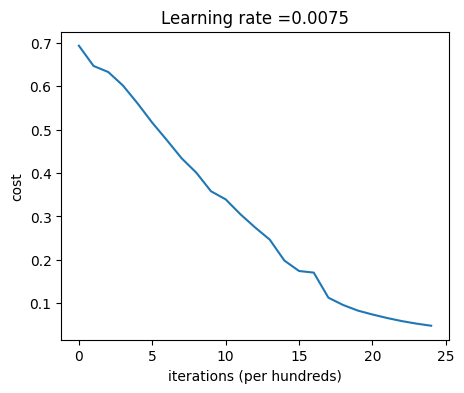

In [43]:
parameters, costs = two_layer_model(
    train_x, train_y, layers_dims=(n_x, n_h, n_y), num_iterations=2500, print_cost=True
)
plot_costs(costs, learning_rate)

In [44]:
predictions_train = predict(train_x, train_y, parameters)

Accuracy: 0.9999999999999998


In [45]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 0.72


In [ ]:
layers_dims = [12288, 20, 7, 5, 1]  #  4-layer model

In [47]:
def L_layer_model(
    X, Y, layers_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False
):
    np.random.seed(1)
    costs = []
    parameters = initialize_parameters_deep(layers_dims)
    for i in range(0, num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        parameters = update_parameters(parameters, grads, learning_rate)
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    return parameters, costs

In [ ]:
parameters, costs = L_layer_model(
    train_x, train_y, layers_dims, num_iterations=1, print_cost=False
)

print("Cost after first iteration: " + str(costs[0]))

L_layer_model_test(L_layer_model)

Cost after first iteration: 0.7717493284237686
 All tests passed.


In [49]:
parameters, costs = L_layer_model(
    train_x, train_y, layers_dims, num_iterations=2500, print_cost=True
)

Cost after iteration 0: 0.7717493284237686
Cost after iteration 100: 0.6720534400822914
Cost after iteration 200: 0.6482632048575212
Cost after iteration 300: 0.6115068816101354
Cost after iteration 400: 0.5670473268366111
Cost after iteration 500: 0.54013766345478
Cost after iteration 600: 0.5279299569455268
Cost after iteration 700: 0.4654773771766853
Cost after iteration 800: 0.36912585249592794
Cost after iteration 900: 0.39174697434805317
Cost after iteration 1000: 0.3151869888600615
Cost after iteration 1100: 0.2726998441789388
Cost after iteration 1200: 0.23741853400268137
Cost after iteration 1300: 0.1996012053220863
Cost after iteration 1400: 0.189263003884633
Cost after iteration 1500: 0.16118854665827748
Cost after iteration 1600: 0.14821389662363316
Cost after iteration 1700: 0.13777487812972944
Cost after iteration 1800: 0.12974017549190112
Cost after iteration 1900: 0.12122535068005201
Cost after iteration 2000: 0.113820606686337
Cost after iteration 2100: 0.1078392852625

In [50]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.9856459330143539


In [51]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.8


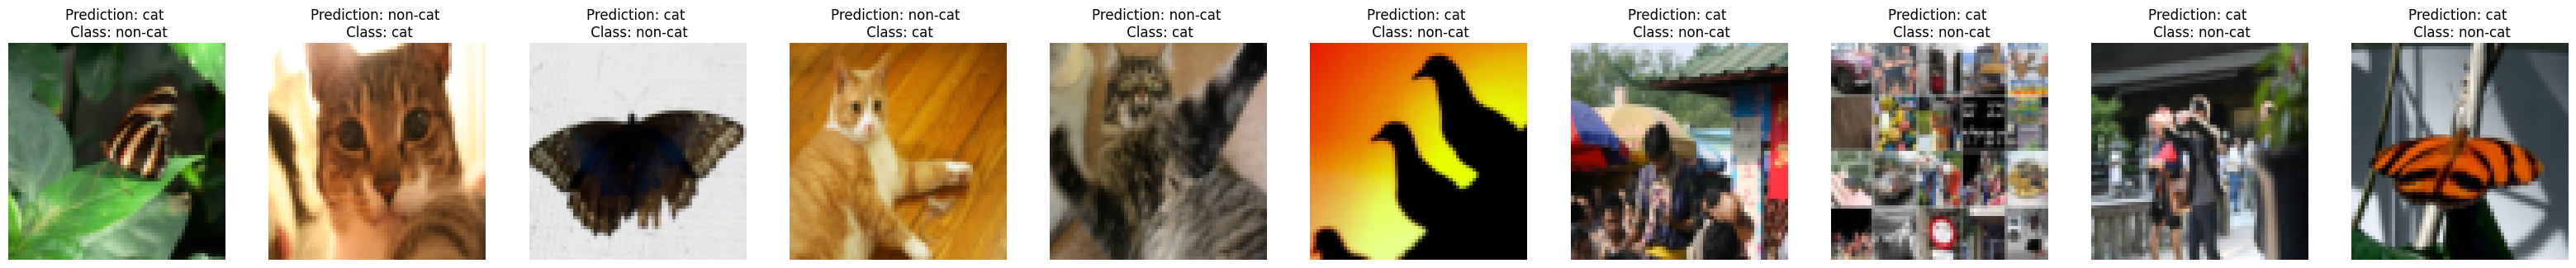

In [52]:
print_mislabeled_images(classes, test_x, test_y, pred_test)

Accuracy: 1.0
y = 1.0, your L-layer model predicts a "cat" picture.


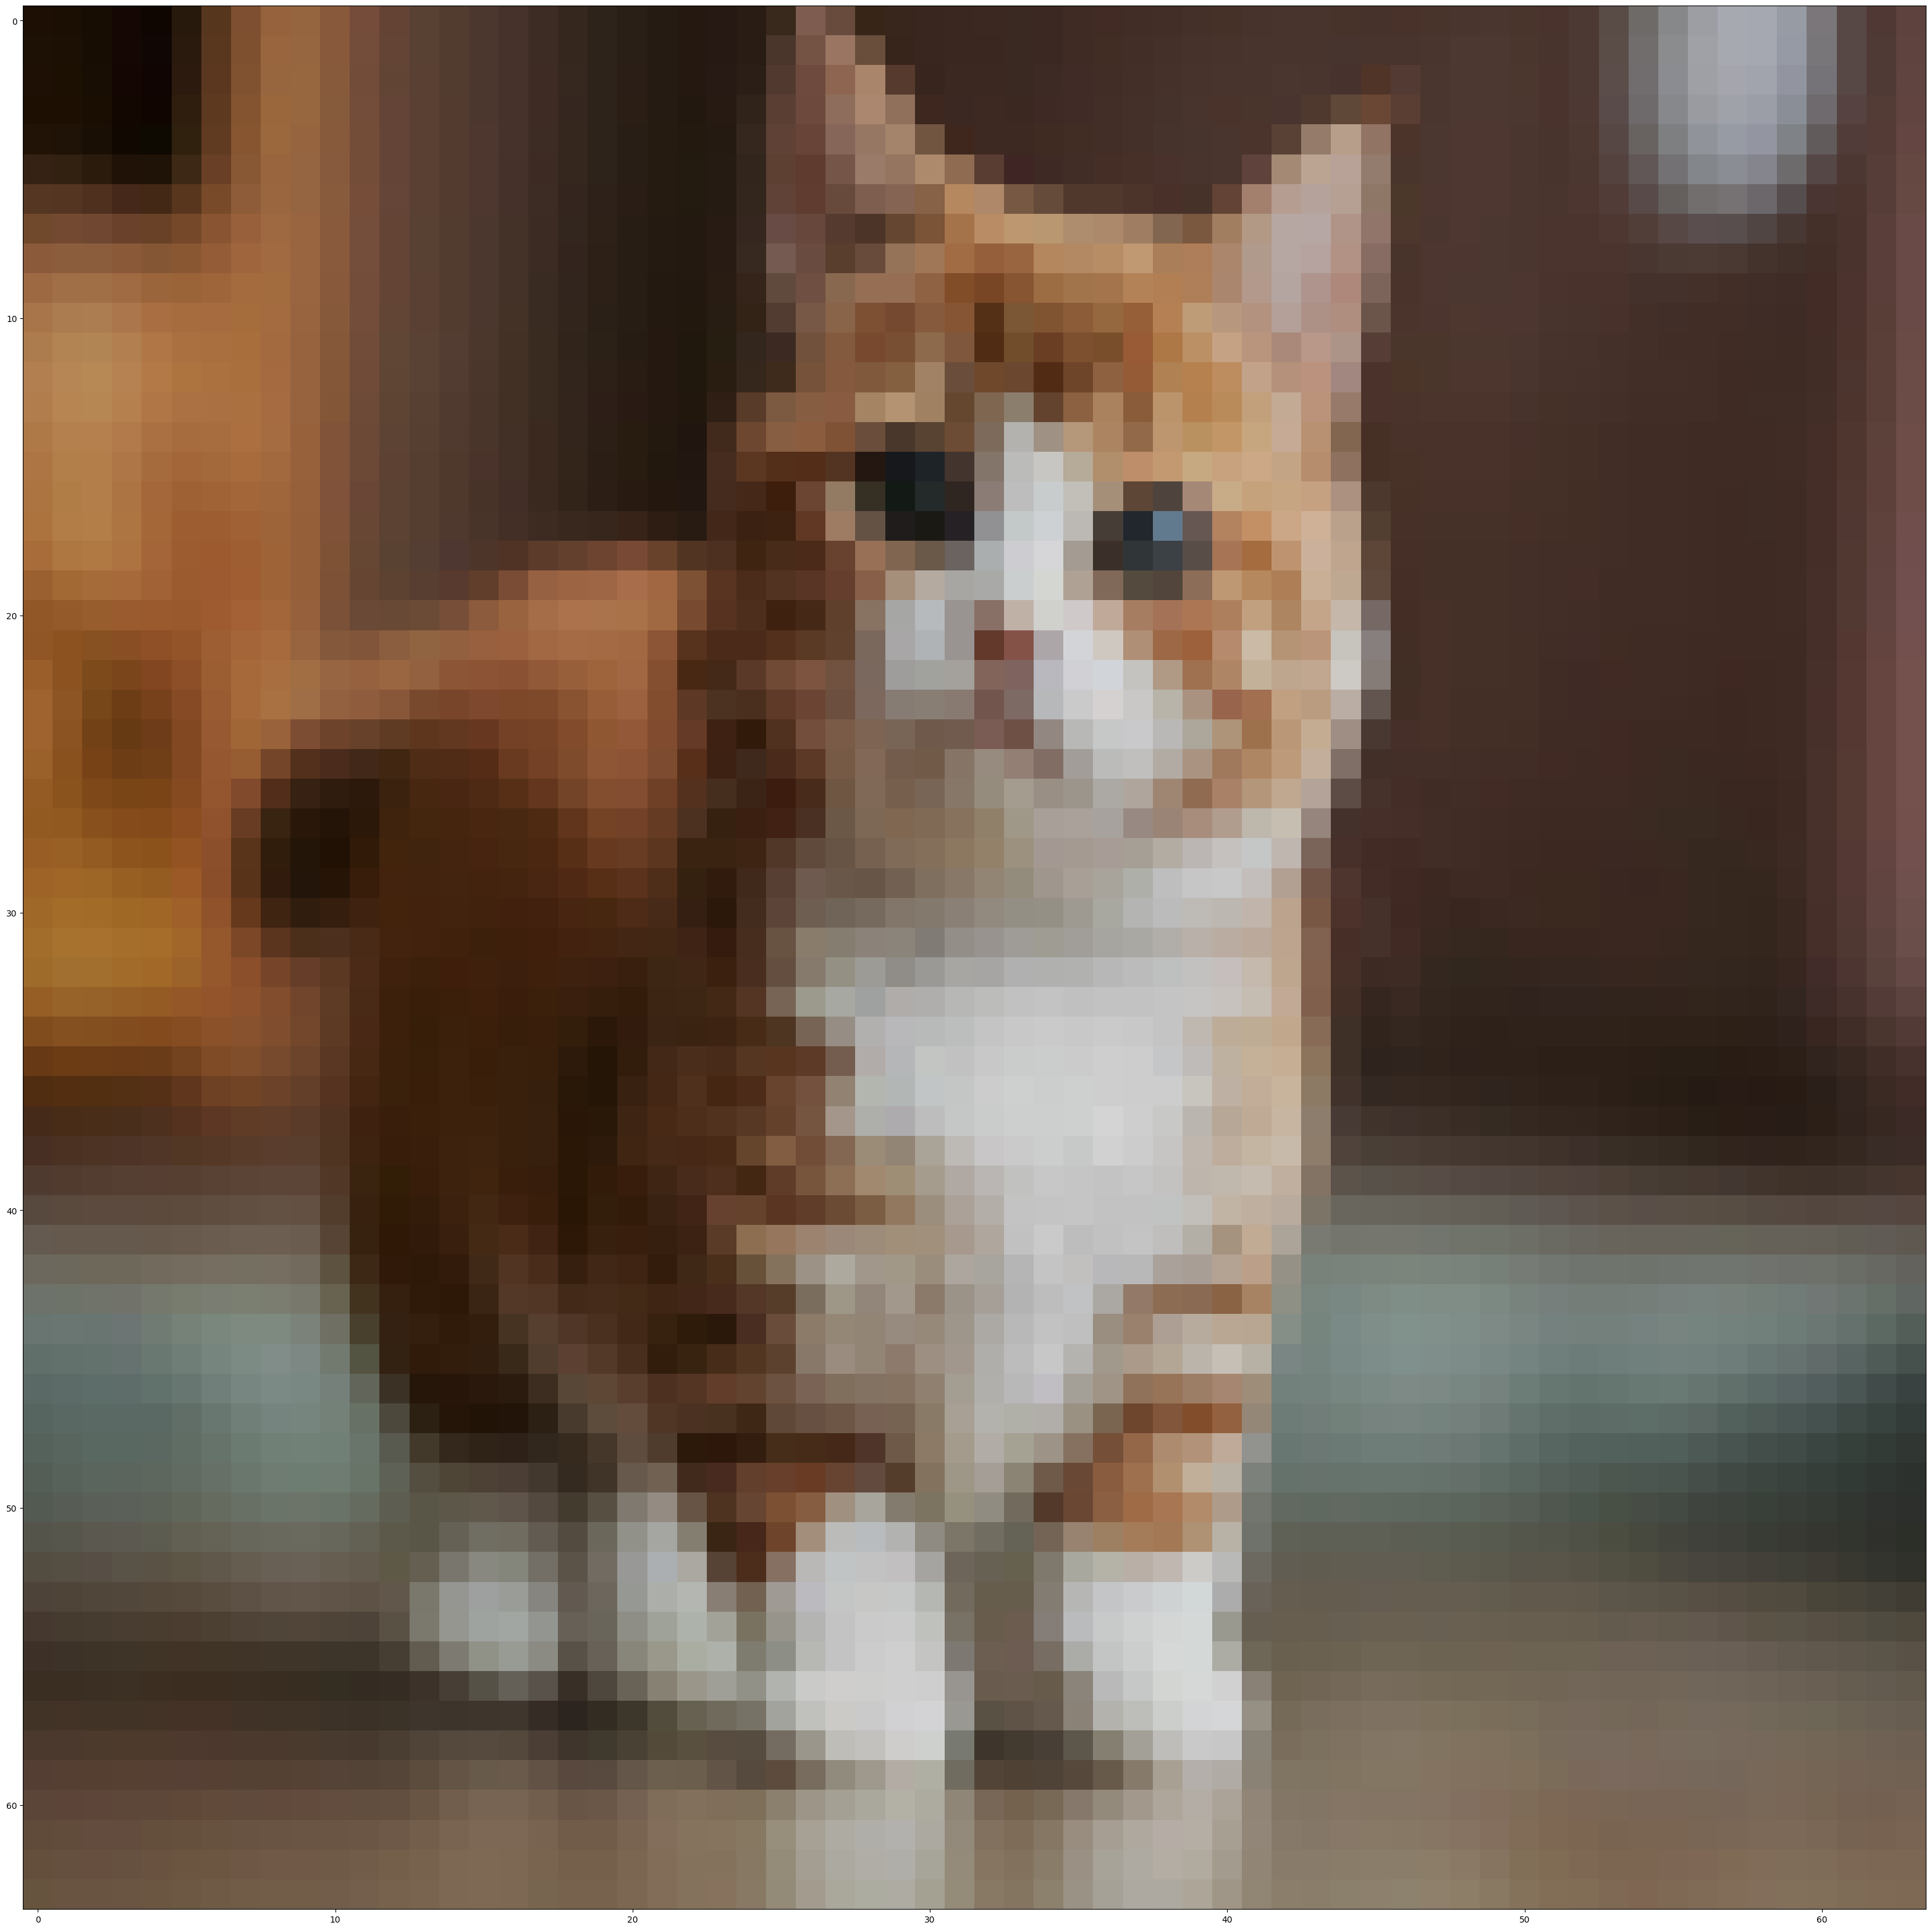

In [ ]:
my_image = "my_image2.jpg"  # change this to the name of your image file
my_label_y = [1]  # the true class of your image (1 -> cat, 0 -> non-cat)

fname = "images/" + my_image
# image = np.array(Image.open(fname).resize((num_px, num_px)))
image = np.array(Image.open(fname).convert("RGB").resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.0
image = image.reshape((1, num_px * num_px * 3)).T
my_predicted_image = predict(image, my_label_y, parameters)

print(
    "y = "
    + str(np.squeeze(my_predicted_image))
    + ', your L-layer model predicts a "'
    + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8")
    + '" picture.'
)